In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is not installed. Activate the project .venv and run: "
        "python -m pip install matplotlib"
    ) from exc

# Locate the repository root automatically. This works when this notebook
# is placed inside notebooks-phase2/.
current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in (current_dir, *current_dir.parents)
     if (folder / "data" / "patient_data_cleaned.csv").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the repository root containing data/patient_data_cleaned.csv"
    )

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
BASELINE_DIR = OUTPUTS_DIR / "original_elcs_baseline"
TASK4_DIR = OUTPUTS_DIR / "improved_elcs_undersampling"
FIGURE_DIR = OUTPUTS_DIR / "report_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures will be saved to:", FIGURE_DIR)


Project root: C:\Users\leoca\Data-Engineering-and-AI-Project
Figures will be saved to: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures


In [2]:
# Helper functions shared by several figures.
def load_target_csv(path):
    """Load a one-column target CSV and safely convert True/False or 0/1 to integers."""
    target = pd.read_csv(path).squeeze("columns")
    if pd.api.types.is_numeric_dtype(target):
        return target.astype(int)
    mapped = (
        target.astype(str).str.strip().str.lower()
        .map({"false": 0, "true": 1, "0": 0, "1": 1})
    )
    if mapped.isna().any():
        raise ValueError(f"Unexpected target value in {path}")
    return mapped.astype(int)


def save_current_figure(filename):
    """Save the current plot as a high-resolution PNG for the report."""
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)


def first_existing_path(paths):
    for path in paths:
        if path.exists():
            return path
    return None


## Figure 1.2.2 — Heart-disease target distribution



Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_1_2_2_target_distribution.png


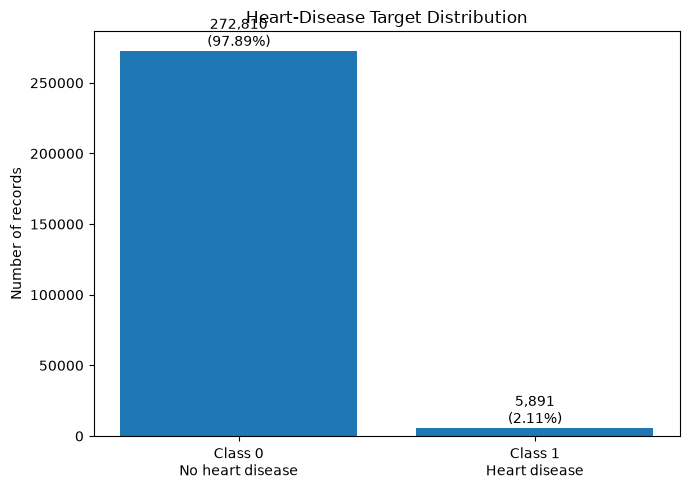

In [3]:
# Shows the severe class imbalance in the cleaned Phase I dataset.
cleaned_data = pd.read_csv(DATA_DIR / "patient_data_cleaned.csv")

raw_target = cleaned_data["heart_disease_target"]

# Convert the target to numeric 0/1 if necessary.
if pd.api.types.is_numeric_dtype(raw_target):
    target = raw_target.astype(int)
else:
    target = (
        raw_target.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "false": 0,
            "true": 1,
            "0": 0,
            "1": 1,
        })
        .astype(int)
    )

# Count class 0 and class 1 records.
counts = target.value_counts().sort_index()

values = [
    counts.get(0, 0),
    counts.get(1, 0),
]

labels = [
    "Class 0\nNo heart disease",
    "Class 1\nHeart disease",
]

# Create the bar chart.
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, values)

ax.set_title("Heart-Disease Target Distribution")
ax.set_ylabel("Number of records")

# Add the raw count and percentage above each bar.
total = sum(values)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}\n({value / total * 100:.2f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

save_current_figure(
    "figure_1_2_2_target_distribution.png"
)

plt.show()

## Figure 2.5.4 — Original eLCS baseline metrics

Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_2_5_4_baseline_metrics.png


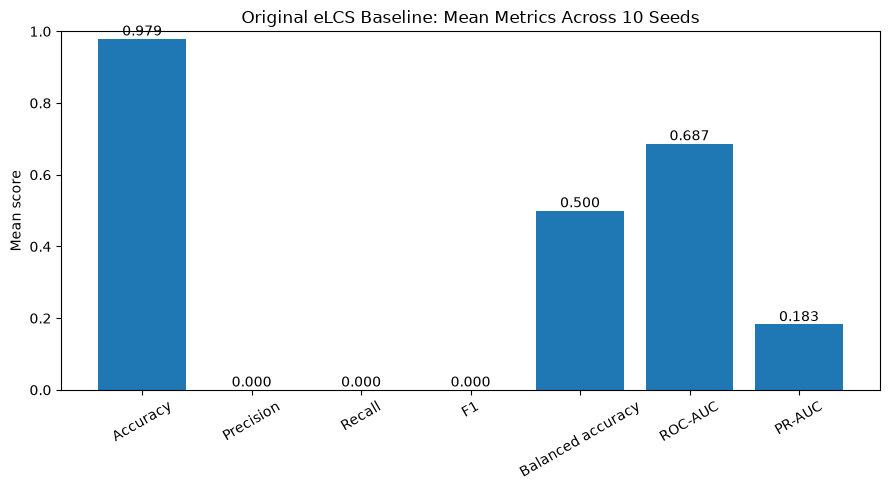

In [4]:
# Reads the summary already saved by Task 2; no model is retrained here.
path = BASELINE_DIR / "baseline_summary.csv"
if not path.exists():
    print("Skipped: run Task_2_Original_eLCS_Baseline.ipynb first.")
else:
    summary = pd.read_csv(path)
    metrics = ["Accuracy","Precision","Recall","F1","Balanced accuracy","ROC-AUC","PR-AUC"]
    data = summary[summary["Metric"].isin(metrics)].set_index("Metric").reindex(metrics)
    fig, ax = plt.subplots(figsize=(9,5))
    bars = ax.bar(data.index, data["mean"])
    ax.set_title("Original eLCS Baseline: Mean Metrics Across 10 Seeds")
    ax.set_ylabel("Mean score")
    ax.set_ylim(0,1)
    ax.tick_params(axis="x", rotation=30)
    for bar, value in zip(bars, data["mean"]):
        ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    save_current_figure("figure_2_5_4_baseline_metrics.png")
    plt.show()


## Figure 2.5.5 — Original eLCS baseline confusion matrix

Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_2_5_5_baseline_confusion_matrix.png


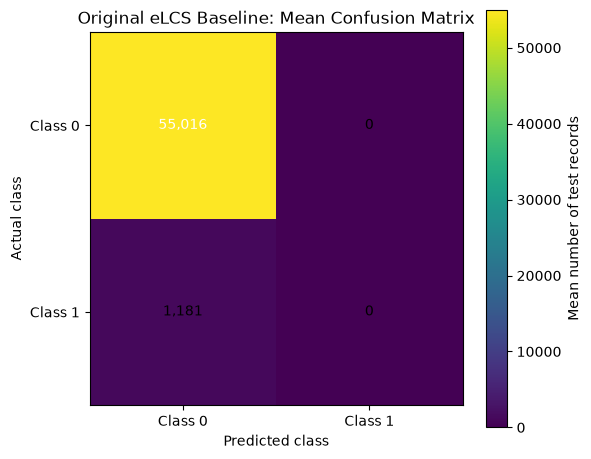

In [5]:
path = BASELINE_DIR / "baseline_runs.csv"
if not path.exists():
    print("Skipped: baseline_runs.csv was not found.")
else:
    runs = pd.read_csv(path)
    matrix = np.array([
        [runs["True negatives"].mean(), runs["False positives"].mean()],
        [runs["False negatives"].mean(), runs["True positives"].mean()],
    ])
    fig, ax = plt.subplots(figsize=(6,5))
    image = ax.imshow(matrix)
    ax.set_title("Original eLCS Baseline: Mean Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticks([0,1],["Class 0","Class 1"])
    ax.set_yticks([0,1],["Class 0","Class 1"])
    threshold = matrix.max()/2 if matrix.max() else 0
    for r in range(2):
        for c in range(2):
            v = matrix[r,c]
            ax.text(c,r,f"{v:,.0f}",ha="center",va="center",
                    color="white" if v>threshold else "black")
    fig.colorbar(image, ax=ax, label="Mean number of test records")
    plt.tight_layout()
    save_current_figure("figure_2_5_5_baseline_confusion_matrix.png")
    plt.show()


## Figure 2.5.6 — Baseline rule-feature frequency



Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_2_5_6_baseline_rule_feature_frequency.png


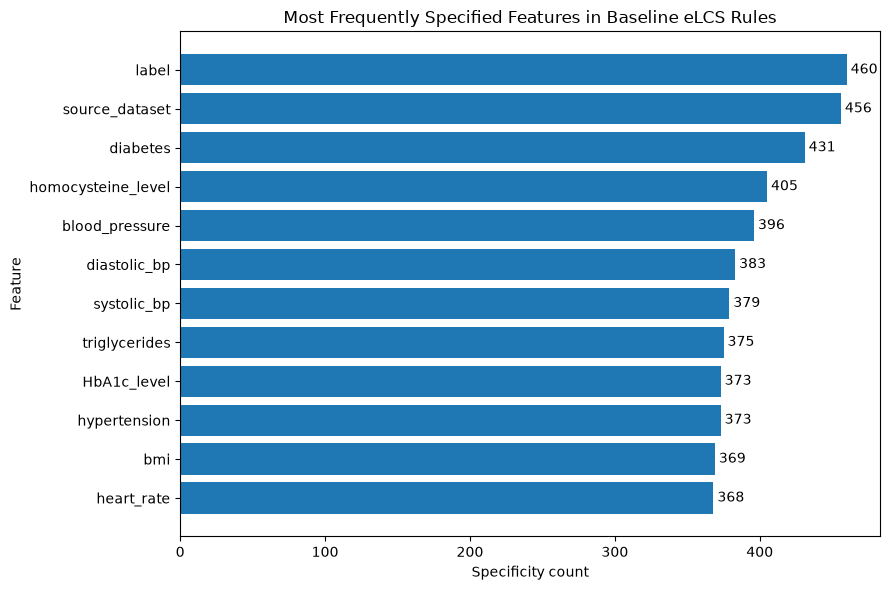

In [6]:
path = BASELINE_DIR / "baseline_attribute_diagnostics.csv"
if not path.exists():
    print("Skipped: baseline_attribute_diagnostics.csv was not found.")
else:
    attrs = pd.read_csv(path)
    top = (attrs.sort_values("Specificity count", ascending=False)
           .head(12).sort_values("Specificity count"))
    fig, ax = plt.subplots(figsize=(9,6))
    bars = ax.barh(top["Feature"], top["Specificity count"])
    ax.set_title("Most Frequently Specified Features in Baseline eLCS Rules")
    ax.set_xlabel("Specificity count")
    ax.set_ylabel("Feature")
    for bar, value in zip(bars, top["Specificity count"]):
        ax.text(value, bar.get_y()+bar.get_height()/2, f" {value:,.0f}", va="center")
    plt.tight_layout()
    save_current_figure("figure_2_5_6_baseline_rule_feature_frequency.png")
    plt.show()


## Figure 3.6.2 — Predictor count through preprocessing


Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_3_6_2_preprocessing_feature_counts.png


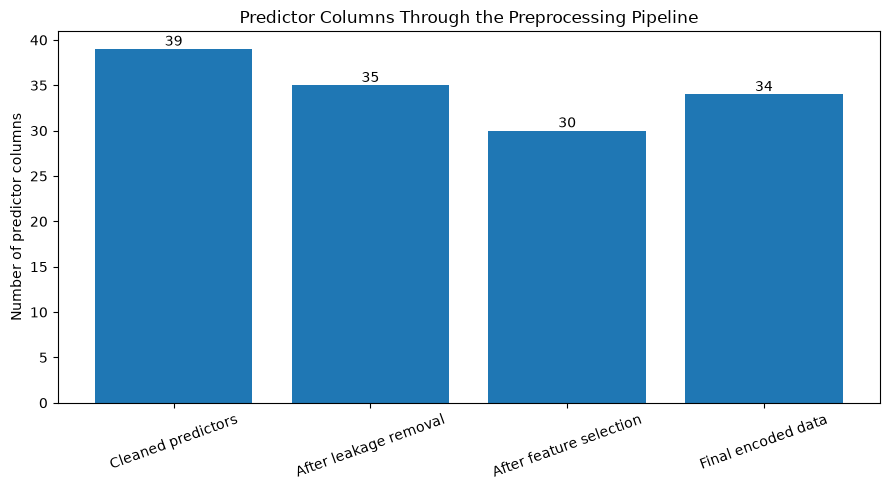

In [7]:
path = DATA_DIR / "X_train_preprocessed_full.csv"
if not path.exists():
    print("Skipped: run Task_3_Data Cleansing and Transformation.ipynb first.")
else:
    initial = cleaned_data.shape[1] - 1  # 40 columns minus target = 39 predictors
    after_leakage = initial - 4          # sublabel, disease_flags, heart_disease, label
    after_selection = after_leakage - 5  # composite_key, source_dataset, age_level, age_normalized, bmi
    final_count = pd.read_csv(path, nrows=1).shape[1]
    stages = ["Cleaned predictors","After leakage removal","After feature selection","Final encoded data"]
    counts = [initial, after_leakage, after_selection, final_count]
    fig, ax = plt.subplots(figsize=(9,5))
    bars = ax.bar(stages, counts)
    ax.set_title("Predictor Columns Through the Preprocessing Pipeline")
    ax.set_ylabel("Number of predictor columns")
    ax.tick_params(axis="x", rotation=20)
    for bar, value in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, value, str(value), ha="center", va="bottom")
    plt.tight_layout()
    save_current_figure("figure_3_6_2_preprocessing_feature_counts.png")
    plt.show()


## Figure 4.1.3 — Class composition before and after undersampling 


Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_4_1_3_undersampling_composition.png


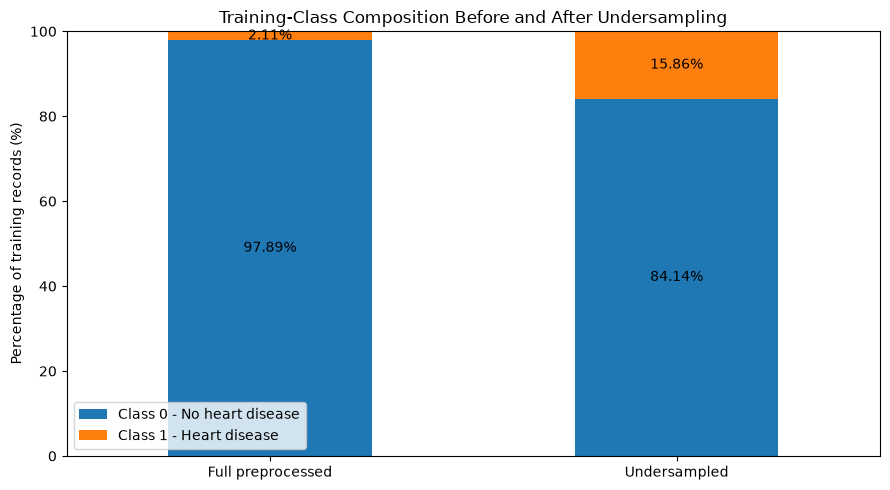

In [8]:
y_full_path = DATA_DIR / "y_train_preprocessed_full.csv"
y_under_path = DATA_DIR / "y_train_preprocessed_undersampled.csv"
if not y_full_path.exists() or not y_under_path.exists():
    print("Skipped: Task 3 target CSVs were not found.")
else:
    y_full = load_target_csv(y_full_path)
    y_under = load_target_csv(y_under_path)
    dist = pd.DataFrame({
        "Full preprocessed": y_full.value_counts(normalize=True).sort_index()*100,
        "Undersampled": y_under.value_counts(normalize=True).sort_index()*100,
    }).T
    dist.columns = ["Class 0 - No heart disease","Class 1 - Heart disease"]
    ax = dist.plot(kind="bar", stacked=True, figsize=(9,5))
    ax.set_title("Training-Class Composition Before and After Undersampling")
    ax.set_ylabel("Percentage of training records (%)")
    ax.set_xlabel("")
    ax.set_ylim(0,100)
    ax.tick_params(axis="x", rotation=0)
    for i, name in enumerate(dist.index):
        c0 = dist.loc[name,"Class 0 - No heart disease"]
        c1 = dist.loc[name,"Class 1 - Heart disease"]
        ax.text(i,c0/2,f"{c0:.2f}%",ha="center",va="center")
        ax.text(i,c0+c1/2,f"{c1:.2f}%",ha="center",va="center")
    plt.tight_layout()
    save_current_figure("figure_4_1_3_undersampling_composition.png")
    plt.show()


## Figure 4.1.4 — Training-set size reduction



Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_4_1_4_training_size_reduction.png


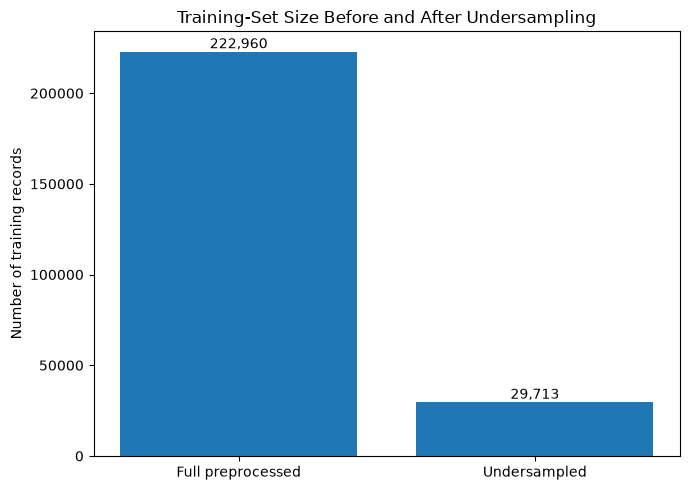

In [9]:
if not y_full_path.exists() or not y_under_path.exists():
    print("Skipped: Task 3 target CSVs were not found.")
else:
    y_full = load_target_csv(y_full_path)
    y_under = load_target_csv(y_under_path)
    labels = ["Full preprocessed","Undersampled"]
    sizes = [len(y_full), len(y_under)]
    fig, ax = plt.subplots(figsize=(7,5))
    bars = ax.bar(labels, sizes)
    ax.set_title("Training-Set Size Before and After Undersampling")
    ax.set_ylabel("Number of training records")
    for bar, value in zip(bars, sizes):
        ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:,}", ha="center", va="bottom")
    plt.tight_layout()
    save_current_figure("figure_4_1_4_training_size_reduction.png")
    plt.show()


## Figure 4.4.1 — Three eLCS configurations compared 


Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_4_4_1_elcs_metric_comparison.png


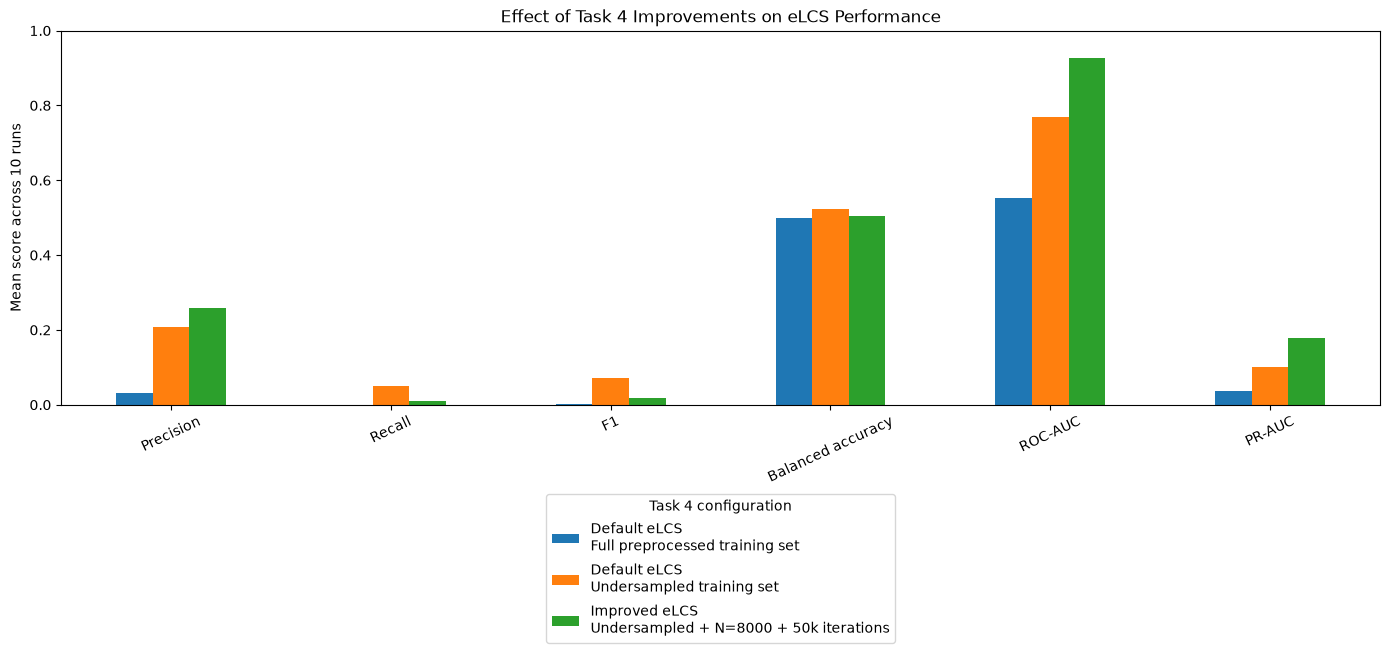

In [24]:
# Figure 4.4.1
# Compares the three Task 4 eLCS configurations using key metrics.

import pandas as pd
import matplotlib.pyplot as plt

task4_summary_path = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
    / "task4_comparison_summary.csv"
)

# Load the saved Task 4 summary results directly from CSV.
task4_summary = pd.read_csv(task4_summary_path)

# Metrics most useful for this highly imbalanced classification problem.
key_metrics = [
    "Precision",
    "Recall",
    "F1",
    "Balanced accuracy",
    "ROC-AUC",
    "PR-AUC",
]

# Reshape the summary so each Task 4 configuration becomes one series.
comparison = (
    task4_summary[
        task4_summary["Metric"].isin(key_metrics)
    ]
    .pivot(
        index="Metric",
        columns="Configuration",
        values="mean",
    )
    .reindex(key_metrics)
)

# Rename the internal configuration names so the diagram clearly
# explains exactly what changed between each system.
comparison = comparison.rename(
    columns={
        "Full preprocessed - default eLCS":
            "Default eLCS\nFull preprocessed training set",

        "Undersampling only - default eLCS":
            "Default eLCS\nUndersampled training set",

        "Undersampled - improved eLCS":
            "Improved eLCS\nUndersampled + N=8000 + 50k iterations",
    }
)

# Force the legend/bar order to:
# 1. Default
# 2. Default + undersampled
# 3. Improved + undersampled
comparison = comparison[
    [
        "Default eLCS\nFull preprocessed training set",
        "Default eLCS\nUndersampled training set",
        "Improved eLCS\nUndersampled + N=8000 + 50k iterations",
    ]
]

# Create the grouped bar chart.
ax = comparison.plot(
    kind="bar",
    figsize=(14, 7),
)

ax.set_title(
    "Effect of Task 4 Improvements on eLCS Performance"
)

ax.set_ylabel(
    "Mean score across 10 runs"
)

ax.set_xlabel("")

ax.set_ylim(0, 1)

ax.tick_params(
    axis="x",
    rotation=25,
)

# Put the detailed configuration descriptions below the graph.
ax.legend(
    title="Task 4 configuration",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=1,
)

plt.tight_layout()

save_current_figure(
    "figure_4_4_1_elcs_metric_comparison.png"
)

plt.show()

## Figure 4.4.2 — Training-time trade-off



Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_4_4_2_training_time.png


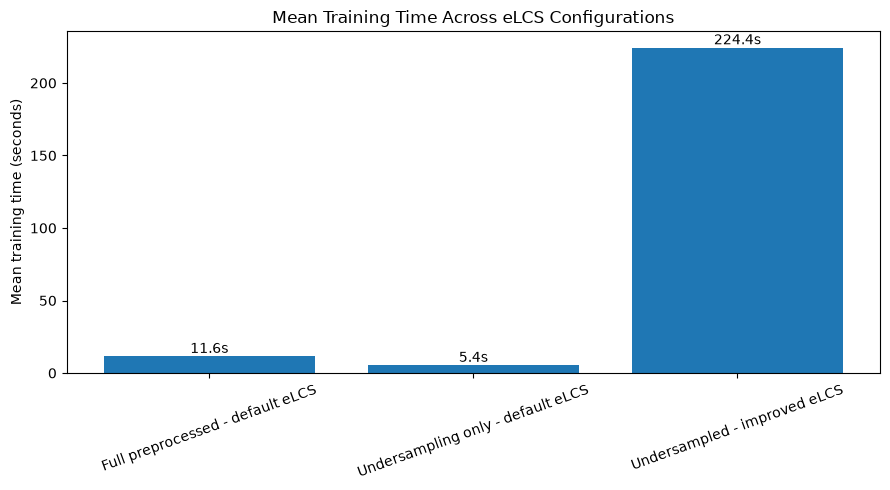

In [11]:
if not task4_summary_path.exists():
    print("Skipped: task4_comparison_summary.csv was not found.")
else:
    summary = pd.read_csv(task4_summary_path)
    timing = summary[summary["Metric"]=="Training seconds"].copy()
    fig, ax = plt.subplots(figsize=(9,5))
    bars = ax.bar(timing["Configuration"], timing["mean"])
    ax.set_title("Mean Training Time Across eLCS Configurations")
    ax.set_ylabel("Mean training time (seconds)")
    ax.tick_params(axis="x", rotation=20)
    for bar, value in zip(bars, timing["mean"]):
        ax.text(bar.get_x()+bar.get_width()/2, value, f"{value:.1f}s", ha="center", va="bottom")
    plt.tight_layout()
    save_current_figure("figure_4_4_2_training_time.png")
    plt.show()


## Figure 5.1.1 — Stratified 80/20 split 



Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_5_1_1_stratified_split.png


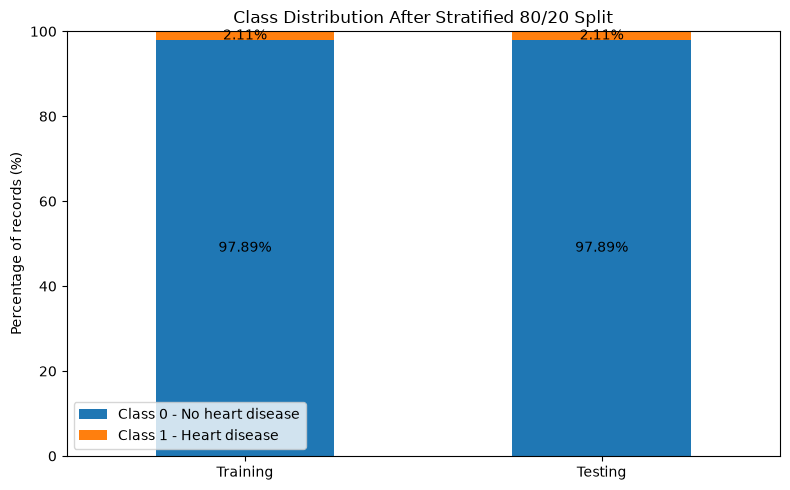

In [12]:
y_test_path = DATA_DIR / "y_test_preprocessed.csv"
if not y_full_path.exists() or not y_test_path.exists():
    print("Skipped: Task 3 target CSVs were not found.")
else:
    y_train = load_target_csv(y_full_path)
    y_test = load_target_csv(y_test_path)
    split = pd.DataFrame({
        "Training": y_train.value_counts(normalize=True).sort_index()*100,
        "Testing": y_test.value_counts(normalize=True).sort_index()*100,
    }).T
    split.columns = ["Class 0 - No heart disease","Class 1 - Heart disease"]
    ax = split.plot(kind="bar", stacked=True, figsize=(8,5))
    ax.set_title("Class Distribution After Stratified 80/20 Split")
    ax.set_ylabel("Percentage of records (%)")
    ax.set_xlabel("")
    ax.set_ylim(0,100)
    ax.tick_params(axis="x", rotation=0)
    for i,name in enumerate(["Training","Testing"]):
        c0 = split.loc[name,"Class 0 - No heart disease"]
        c1 = split.loc[name,"Class 1 - Heart disease"]
        ax.text(i,c0/2,f"{c0:.2f}%",ha="center",va="center")
        ax.text(i,c0+c1/2,f"{c1:.2f}%",ha="center",va="center")
    plt.tight_layout()
    save_current_figure("figure_5_1_1_stratified_split.png")
    plt.show()


## Figure 5.2.1 — Final improved-eLCS confusion matrix


Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_5_2_1_improved_confusion_matrix.png


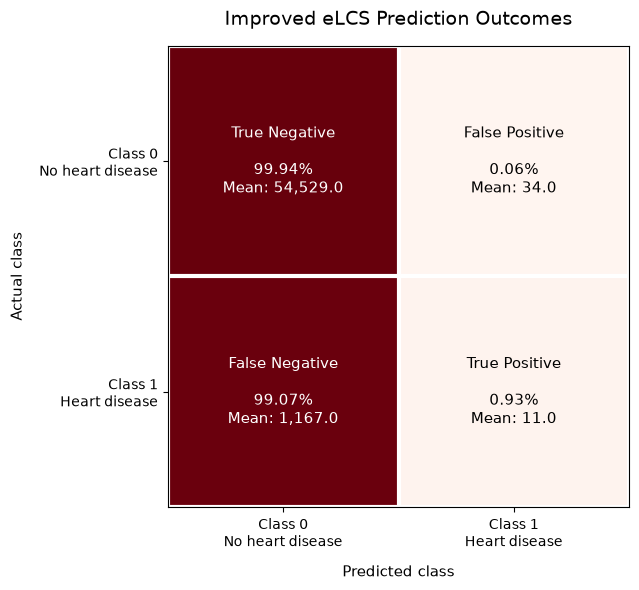

In [26]:
# Figure 5.2.1
# Normalised confusion matrix for the final improved eLCS.
# Percentages are calculated within each actual class.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

improved_runs_path = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
    / "undersampled_improved_elcs_runs.csv"
)

# Load the 10 improved-eLCS experiment results.
improved_runs = pd.read_csv(improved_runs_path)

# Mean confusion-matrix counts across the 10 runs.
tn = improved_runs["True negatives"].mean()
fp = improved_runs["False positives"].mean()
fn = improved_runs["False negatives"].mean()
tp = improved_runs["True positives"].mean()

# Total actual records in each class.
actual_negative = tn + fp
actual_positive = fn + tp

# Convert counts into percentages within each actual class.
normalised_matrix = np.array([
    [
        tn / actual_negative * 100,
        fp / actual_negative * 100,
    ],
    [
        fn / actual_positive * 100,
        tp / actual_positive * 100,
    ],
])

count_matrix = np.array([
    [tn, fp],
    [fn, tp],
])

cell_names = np.array([
    ["True Negative", "False Positive"],
    ["False Negative", "True Positive"],
])

fig, ax = plt.subplots(figsize=(8, 6))

# Use a subtle red colour scale.
ax.imshow(
    normalised_matrix,
    cmap="Reds",
    vmin=0,
    vmax=100,
)

ax.set_title(
    "Improved eLCS Prediction Outcomes",
    fontsize=14,
    pad=15,
)

ax.set_xlabel(
    "Predicted class",
    fontsize=11,
    labelpad=10,
)

ax.set_ylabel(
    "Actual class",
    fontsize=11,
    labelpad=10,
)

ax.set_xticks(
    [0, 1],
    [
        "Class 0\nNo heart disease",
        "Class 1\nHeart disease",
    ],
)

ax.set_yticks(
    [0, 1],
    [
        "Class 0\nNo heart disease",
        "Class 1\nHeart disease",
    ],
)

# Add a clear label, percentage, and mean count inside each cell.
for row in range(2):
    for column in range(2):
        percentage = normalised_matrix[row, column]
        count = count_matrix[row, column]

        ax.text(
            column,
            row,
            (
                f"{cell_names[row, column]}\n\n"
                f"{percentage:.2f}%\n"
                f"Mean: {count:,.1f}"
            ),
            ha="center",
            va="center",
            fontsize=11,
            color="white" if percentage > 50 else "black",
        )

# Add clean white borders between the four cells.
ax.set_xticks(
    np.arange(-0.5, 2, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, 2, 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linewidth=3,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

plt.tight_layout()

save_current_figure(
    "figure_5_2_1_improved_confusion_matrix.png"
)

plt.show()


## Figure 5.3.1 — Balanced accuracy across seeds

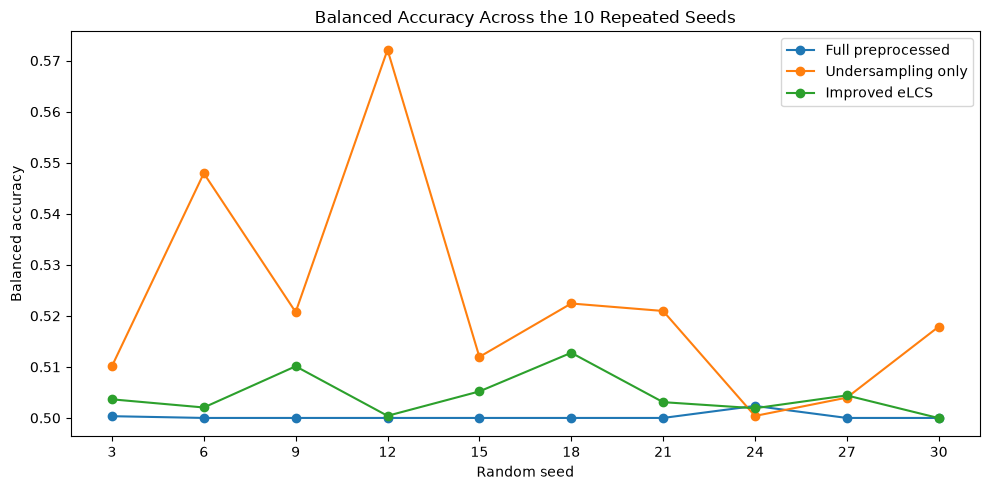

In [14]:
# Figure 5.3.1
# Compares balanced accuracy across the same 10 seeds
# for all three eLCS configurations.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root.
current_dir = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        folder
        for folder in (current_dir, *current_dir.parents)
        if (folder / "data" / "patient_data_cleaned.csv").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root.")

# Locate the Task 4 result files.
TASK4_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
)

full_runs_path = (
    TASK4_DIR
    / "full_preprocessed_default_runs.csv"
)

undersampling_runs_path = (
    TASK4_DIR
    / "undersampling_only_default_runs.csv"
)

improved_runs_path = (
    TASK4_DIR
    / "undersampled_improved_elcs_runs.csv"
)

required_files = [
    full_runs_path,
    undersampling_runs_path,
    improved_runs_path,
]

# Check that all three result files exist.
if not all(path.exists() for path in required_files):
    raise FileNotFoundError(
        "One or more Task 4 result CSV files could not be found."
    )

# Load and sort the results by seed.
full_runs = (
    pd.read_csv(full_runs_path)
    .sort_values("Seed")
)

undersampling_runs = (
    pd.read_csv(undersampling_runs_path)
    .sort_values("Seed")
)

improved_runs = (
    pd.read_csv(improved_runs_path)
    .sort_values("Seed")
)

# Create the line graph.
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    full_runs["Seed"],
    full_runs["Balanced accuracy"],
    marker="o",
    label="Full preprocessed",
)

ax.plot(
    undersampling_runs["Seed"],
    undersampling_runs["Balanced accuracy"],
    marker="o",
    label="Undersampling only",
)

ax.plot(
    improved_runs["Seed"],
    improved_runs["Balanced accuracy"],
    marker="o",
    label="Improved eLCS",
)

ax.set_title("Balanced Accuracy Across the 10 Repeated Seeds")
ax.set_xlabel("Random seed")
ax.set_ylabel("Balanced accuracy")

# Display every seed used in the experiments.
ax.set_xticks(full_runs["Seed"])

ax.legend()

plt.tight_layout()

# Save the figure.
figure_dir = PROJECT_ROOT / "outputs" / "report_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_dir / "figure_5_3_1_balanced_accuracy_by_seed.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Figure 5.3.2 — PR-AUC across the same 10 seeds


Saved: C:\Users\leoca\Data-Engineering-and-AI-Project\outputs\report_figures\figure_5_3_2_pr_auc_by_seed.png


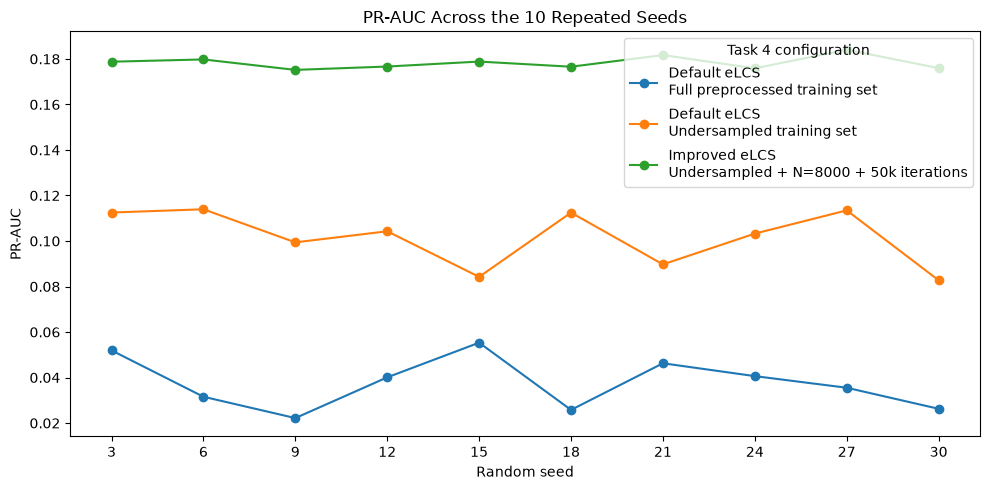

In [30]:
# Figure 5.3.2
# Compares PR-AUC across the same 10 seeds
# for the three Task 4 eLCS configurations.

import pandas as pd
import matplotlib.pyplot as plt

# Define the three Task 4 result files.
full_runs_path = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
    / "full_preprocessed_default_runs.csv"
)

undersampling_runs_path = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
    / "undersampling_only_default_runs.csv"
)

improved_runs_path = (
    PROJECT_ROOT
    / "outputs"
    / "improved_elcs_undersampling"
    / "undersampled_improved_elcs_runs.csv"
)

# Check that all three CSV files exist.
required_files = [
    full_runs_path,
    undersampling_runs_path,
    improved_runs_path,
]

if not all(path.exists() for path in required_files):
    print(
        "Skipped Figure 5.3.2 because one or more "
        "Task 4 result CSVs were not found."
    )

else:
    # Load the actual experiment results directly from the CSV files
    # and sort them so that the seeds appear in the correct order.
    full = (
        pd.read_csv(full_runs_path)
        .sort_values("Seed")
    )

    undersampled = (
        pd.read_csv(undersampling_runs_path)
        .sort_values("Seed")
    )

    improved = (
        pd.read_csv(improved_runs_path)
        .sort_values("Seed")
    )

    # Create the line graph.
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.plot(
        full["Seed"],
        full["PR-AUC"],
        marker="o",
        label="Default eLCS\nFull preprocessed training set",
    )

    ax.plot(
        undersampled["Seed"],
        undersampled["PR-AUC"],
        marker="o",
        label="Default eLCS\nUndersampled training set",
    )

    ax.plot(
        improved["Seed"],
        improved["PR-AUC"],
        marker="o",
        label="Improved eLCS\nUndersampled + N=8000 + 50k iterations",
    )

    ax.set_title(
        "PR-AUC Across the 10 Repeated Seeds"
    )

    ax.set_xlabel(
        "Random seed"
    )

    ax.set_ylabel(
        "PR-AUC"
    )

    # Display every seed used in the experiments.
    ax.set_xticks(
        full["Seed"]
    )

    ax.legend(
        title="Task 4 configuration"
    )

    plt.tight_layout()

    save_current_figure(
        "figure_5_3_2_pr_auc_by_seed.png"
    )

    plt.show()